# Häufigkeitstabelle – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/h%C3%A4ufigkeitstabelle)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 20.01.2026

Eine **Häufigkeitstabelle** zeigt, wie oft bestimmte Werte oder Kategorien
(Ausprägungen) in einem Datensatz vorkommen. Sie ist eines der grundlegendsten
Werkzeuge der deskriptiven Statistik.

**Wozu dient sie?**
- Schnellen Überblick über die Verteilung einer Variable geben
- Trends und Muster erkennen
- Grundlage für grafische Darstellungen (Balkendiagramm, Histogramm)

| Spalte | Bedeutung |
|---|---|
| **Absolute Häufigkeit** | Anzahl, wie oft jede Ausprä­gung vorkommt |
| **Relative Häufigkeit (Prozent)** | Anteil bezogen auf **alle** Fälle (inkl. fehlende) |
| **Gültige Prozente** | Anteil bezogen auf nur **gültige** (nicht-fehlende) Fälle |
| **Kumulierte Prozente** | Aufaddierte gültige Prozente |

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Einfaches Beispiel: Variable "Geschlecht"

**Datensatz:** 10 Personen werden nach ihrem Geschlecht befragt.

| Person | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| Geschlecht | m | w | w | m | w | m | w | w | m | w |

**Berechnung:**
- männlich: 4 Personen → absolute Häufigkeit = 4, relativ = 4/10 × 100 = **40 %**
- weiblich:  6 Personen → absolute Häufigkeit = 6, relativ = 6/10 × 100 = **60 %**

**Ergebnis (Häufigkeitstabelle):**

| Geschlecht | Abs. Häufigkeit | Prozent | Gültige Prozente |
|---|---|---|---|
| männlich | 4 | 40 % | 40 % |
| weiblich | 6 | 60 % | 60 % |
| **Gesamt** | **10** | **100 %** | **100 %** |

Häufigkeitstabelle: Geschlecht
            Abs. Häufigkeit  Prozent (%)  Gültige Proz.(%)
Geschlecht                                                
weiblich                6.0         60.0              60.0
männlich                4.0         40.0              40.0
Gesamt                 10.0        100.0             100.0


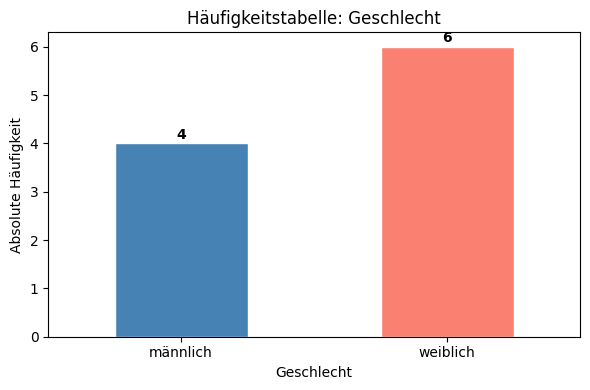

In [30]:
# numiqo-Beispiel 1: Geschlecht
geschlecht = pd.Series(["männlich","weiblich","weiblich","männlich","weiblich",
                         "männlich","weiblich","weiblich","männlich","weiblich"])

n_gesamt = len(geschlecht)
abs_hauf  = geschlecht.value_counts()
rel_hauf  = (abs_hauf / n_gesamt * 100).round(1)

tabelle = pd.DataFrame({
    "Abs. Häufigkeit": abs_hauf,
    "Prozent (%)":      rel_hauf,
    "Gültige Proz.(%)": rel_hauf,   # keine fehlenden Werte
})
tabelle.index.name = "Geschlecht"
tabelle.loc["Gesamt"] = [abs_hauf.sum(), rel_hauf.sum().round(1), rel_hauf.sum().round(1)]

print("Häufigkeitstabelle: Geschlecht")
print(tabelle.to_string())

# Balkendiagramm
fig, ax = plt.subplots(figsize=(6, 4))
farben = ["steelblue", "salmon"]
abs_hauf.sort_index().plot(kind="bar", ax=ax, color=farben, edgecolor="white", width=0.5)
ax.set_title("Häufigkeitstabelle: Geschlecht")
ax.set_xlabel("Geschlecht")
ax.set_ylabel("Absolute Häufigkeit")
ax.set_xticklabels(abs_hauf.sort_index().index, rotation=0)
for i, v in enumerate(abs_hauf.sort_index()):
    ax.text(i, v + 0.1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Absolute und relative Häufigkeit

### Absolute Häufigkeit $n_i$
Gibt an, **wie oft** eine bestimmte Ausprä­gung in den Daten vorkommt.

$$n_i = \text{Anzahl der Beobachtungen mit Ausprä­gung } i$$

### Relative Häufigkeit $f_i$
Gibt den **Anteil** einer Ausprä­gung an der Gesamtzahl aller Beobachtungen an.

$$f_i = \frac{n_i}{n} \quad \text{bzw. als Prozent:} \quad f_i = \frac{n_i}{n} \times 100$$

**Eigenschaften:**
- Die Summe aller absoluten Häufigkeiten ergibt $n$ (Gesamtzahl)
- Die Summe aller relativen Häufigkeiten ergibt 1 (bzw. 100 %)

## 3. Gültige Prozente und fehlende Werte

Bei Umfragen antworten manche Personen mit **"Kann ich nicht sagen"**, **"Weiss nicht"**
oder lassen die Frage offen → **fehlende Werte**.

**Problem:** Werden fehlende Werte bei der Prozentuierung mitgezählt, verzerren
sie die Ergebnisse.

**Lösung:** Gültige Prozente – berechnet nur aus den **gültigen (nicht-fehlenden)** Fällen:

$$\text{Gueltige Prozente}_i = \frac{n_i}{n_{\text{gueltig}}} \times 100$$

### Beispiel (numiqo): Automarken-Umfrage mit fehlendem Wert

| Studierende | Automarke |
|---|---|
| 1 | VW |
| 2 | *(keine Angabe)* |
| 3 | BMW |
| 4 | Skoda |
| 5 | Skoda |
| 6 | VW |
| 7 | BMW |
| 8 | Opel |
| 9 | Opel |
| 10 | Skoda |
| 11 | VW |
| 12 | Daimler |

→ 12 Befragte gesamt, **11 gültige** Antworten (1 fehlend)

In [32]:
# numiqo-Beispiel 2: Automarken mit fehlendem Wert
automarken_raw = pd.Series(["VW", None, "BMW", "Skoda", "Skoda", "VW",
                              "BMW", "Opel", "Opel", "Skoda", "VW", "Daimler"])


n_gesamt  = len(automarken_raw)
n_gueltig = automarken_raw.notna().sum()
n_fehlend = automarken_raw.isna().sum()

def faelle(n):
    return "Fall" if n == 1 else "Fälle"

print(f"Gesamt:   {n_gesamt} {faelle(n_gesamt)}")
print(f"Gültig:  {n_gueltig} {faelle(n_gueltig)}")
print(f"Fehlend:  {n_fehlend} {faelle(n_fehlend)}")
print()

# Berechnung
abs_hauf  = automarken_raw.value_counts(dropna=True).sort_values(ascending=False)
proz      = (abs_hauf / n_gesamt  * 100).round(1)
guelt_proz= (abs_hauf / n_gueltig * 100).round(1)
kum_proz  = guelt_proz.cumsum().round(1)

tabelle2 = pd.DataFrame({
    "Abs. Häufigkeit":   abs_hauf,
    "Prozent (%)":        proz,
    "Gültige Proz.(%)":  guelt_proz,
    "Kum. Proz.(%)":      kum_proz,
})

# Fehlende Werte als eigene Zeile
fehlend_row = pd.DataFrame({
    "Abs. Häufigkeit":  [n_fehlend],
    "Prozent (%)":       [round(n_fehlend / n_gesamt * 100, 1)],
    "Gültige Proz.(%)": ["—"],
    "Kum. Proz.(%)":     ["—"],
}, index=["(keine Angabe)"])

gesamt_row = pd.DataFrame({
    "Abs. Häufigkeit":  [n_gesamt],
    "Prozent (%)":       [100.0],
    "Gültige Proz.(%)": [100.0],
    "Kum. Proz.(%)":     ["—"],
}, index=["Gesamt"])

tabelle2 = pd.concat([tabelle2, fehlend_row, gesamt_row])
tabelle2.index.name = "Automarke"

print("Häufigkeitstabelle: Automarke (mit fehlendem Wert)")
print(tabelle2.to_string())

Gesamt:   12 Fälle
Gültig:  11 Fälle
Fehlend:  1 Fall

Häufigkeitstabelle: Automarke (mit fehlendem Wert)
                Abs. Häufigkeit  Prozent (%) Gültige Proz.(%) Kum. Proz.(%)
Automarke                                                                  
VW                            3         25.0             27.3          27.3
Skoda                         3         25.0             27.3          54.6
BMW                           2         16.7             18.2          72.8
Opel                          2         16.7             18.2          91.0
Daimler                       1          8.3              9.1         100.1
(keine Angabe)                1          8.3                —             —
Gesamt                       12        100.0            100.0             —


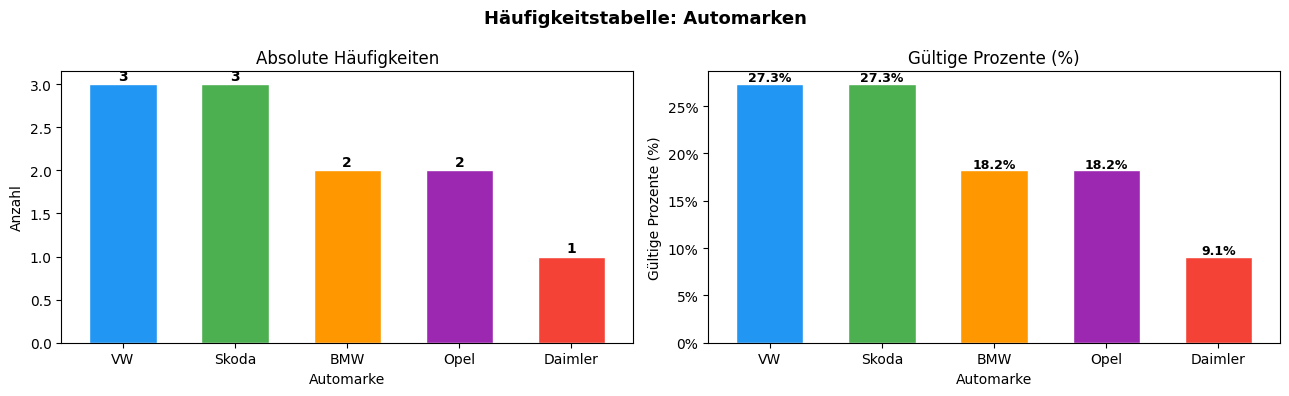

In [34]:
# Visualisierung: Balkendiagramm Automarken
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Häufigkeitstabelle: Automarken", fontsize=13, fontweight="bold")

farben_auto = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336"]

# Links: absolute Häufigkeit
abs_hauf.plot(kind="bar", ax=axes[0], color=farben_auto, edgecolor="white", width=0.6)
axes[0].set_title("Absolute Häufigkeiten")
axes[0].set_xlabel("Automarke")
axes[0].set_ylabel("Anzahl")
axes[0].set_xticklabels(abs_hauf.index, rotation=0)
for i, v in enumerate(abs_hauf):
    axes[0].text(i, v + 0.05, str(v), ha="center", fontsize=10, fontweight="bold")

# Rechts: gültige Prozente
guelt_proz.plot(kind="bar", ax=axes[1], color=farben_auto, edgecolor="white", width=0.6)
axes[1].set_title("Gültige Prozente (%)")
axes[1].set_xlabel("Automarke")
axes[1].set_ylabel("Gültige Prozente (%)")
axes[1].set_xticklabels(guelt_proz.index, rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for i, v in enumerate(guelt_proz):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Kumulierte Häufigkeiten

Die **kumulierten (aufaddierten) Häufigkeiten** geben an, wie viele Beobachtungen
einen Wert **kleiner oder gleich** einem bestimmten Wert aufweisen.

$$F_i = \sum_{j=1}^{i} f_j$$

Kumulierte Häufigkeiten sind besonders nützlich bei:
- **Ordinalen** und **metrischen** Variablen (wo eine Reihenfolge sinnvoll ist)
- Der Berechnung von **Perzentilen** und dem **Median**
- Der Erstellung von **Ogiven** (kumulativen Häufigkeitskurven)

> Tipp: Der **Median** ist genau der Wert, bei dem die kumulierte relative Häufigkeit
> erstmals 50 % erreicht oder überschreitet.

Kumulierte Häufigkeitstabelle: Schulnoten
      Abs. Häufigkeit  Rel. Häuf. (%)  Kum. abs. Häuf.  Kum. rel. Häuf.(%)
Note                                                                      
1                   2            16.7                2                16.7
2                   3            25.0                5                41.7
3                   4            33.3                9                75.0
4                   2            16.7               11                91.7
5                   1             8.3               12               100.0

Median: 3.0 (kum. Häuf. erreicht 50% bei Note 3.0)


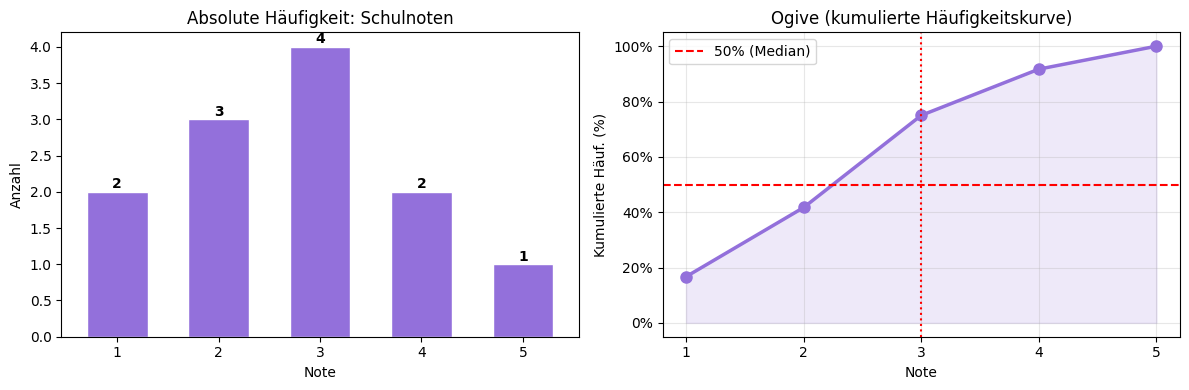

In [26]:
# Kumulierte Häufigkeiten – Beispiel: Schulnoten
noten_data = pd.Series([1, 1, 2, 2, 2, 3, 3, 3, 3, 4, 4, 5])

abs_n  = noten_data.value_counts().sort_index()
rel_n  = (abs_n / len(noten_data) * 100).round(1)
kum_n  = rel_n.cumsum().round(1)
kum_abs= abs_n.cumsum()

tabelle_noten = pd.DataFrame({
    "Abs. Häufigkeit":   abs_n,
    "Rel. Häuf. (%)":    rel_n,
    "Kum. abs. Häuf.":   kum_abs,
    "Kum. rel. Häuf.(%)":kum_n,
})
tabelle_noten.index.name = "Note"
print("Kumulierte Häufigkeitstabelle: Schulnoten")
print(tabelle_noten.to_string())
print()
median_note = noten_data.median()
print(f"Median: {median_note} (kum. Häuf. erreicht 50% bei Note {median_note})")

# Ogive (kumulierte Häufigkeitskurve)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Balkendiagramm
abs_n.plot(kind="bar", ax=axes[0], color="mediumpurple",
           edgecolor="white", width=0.6)
axes[0].set_title("Absolute Häufigkeit: Schulnoten")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Anzahl")
axes[0].set_xticklabels(abs_n.index, rotation=0)
for i, v in enumerate(abs_n):
    axes[0].text(i, v + 0.05, str(v), ha="center", fontweight="bold")

# Ogive
axes[1].plot(kum_n.index, kum_n.values, marker="o", color="mediumpurple",
             linewidth=2.5, markersize=8)
axes[1].fill_between(kum_n.index, kum_n.values, alpha=0.15, color="mediumpurple")
axes[1].axhline(50, color="red", linestyle="--", linewidth=1.5, label="50% (Median)")
axes[1].axvline(median_note, color="red", linestyle=":", linewidth=1.5)
axes[1].set_title("Ogive (kumulierte Häufigkeitskurve)")
axes[1].set_xlabel("Note")
axes[1].set_ylabel("Kumulierte Häuf. (%)")
axes[1].set_xticks(kum_n.index)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Häufigkeitstabelle für metrische Variablen (Klassenbildung)

Bei **metrischen Variablen** mit vielen verschiedenen Werten (z. B. Alter, Einkommen)
werden die Werte in **Klassen (Intervalle)** zusammengefasst.

**Faustregel für Klassenanzahl:** $k \approx \sqrt{n}$ (Wurzel der Fallzahl)

Für die Darstellung wird dann ein **Histogramm** statt eines Balkendiagramms verwendet,
da die x-Achse kontinuierlich ist.

n = 50, k = 7 Klassen

Häufigkeitstabelle: Alter (klassiert)
                  Abs. Häufigkeit  Rel. Häuf. (%)  Kum. rel. Häuf.(%)
Altersklasse                                                         
(17.964, 23.143]               10            20.0                20.0
(23.143, 28.286]                4             8.0                28.0
(28.286, 33.429]               13            26.0                54.0
(33.429, 38.571]               11            22.0                76.0
(38.571, 43.714]                7            14.0                90.0
(43.714, 48.857]                1             2.0                92.0
(48.857, 54.0]                  4             8.0               100.0


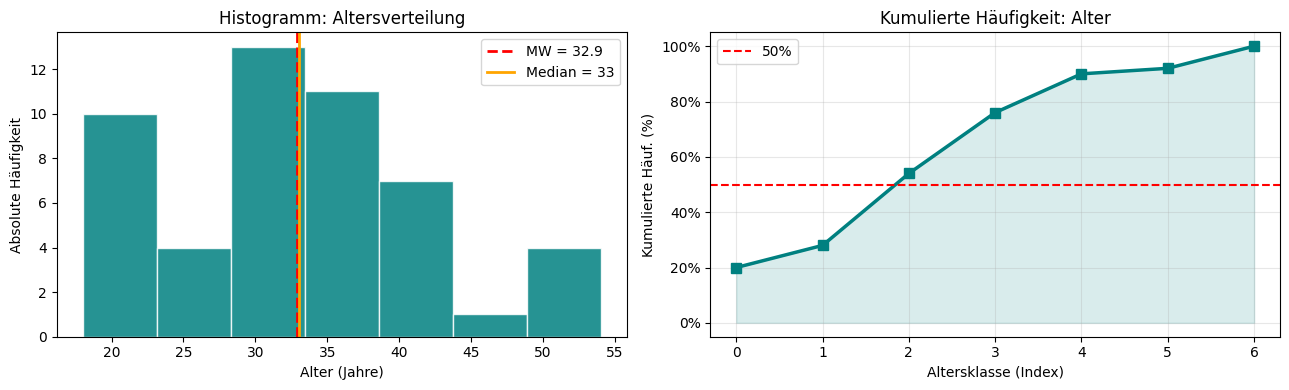

In [ ]:
# Häufigkeitstabelle für metrische Variable: Alter
np.random.seed(42)
alter = pd.Series(np.random.normal(35, 10, 50).clip(18, 65).round(0).astype(int))

# Klassen bilden
k = int(np.sqrt(len(alter)))
bins = pd.cut(alter, bins=k)
abs_kl  = bins.value_counts().sort_index()
rel_kl  = (abs_kl / len(alter) * 100).round(1)
kum_kl  = rel_kl.cumsum().round(1)

tabelle_alter = pd.DataFrame({
    "Abs. Häufigkeit":   abs_kl,
    "Rel. Häuf. (%)":    rel_kl,
    "Kum. rel. Häuf.(%)":kum_kl,
})
tabelle_alter.index.name = "Altersklasse"
print(f"n = {len(alter)}, k = {k} Klassen")
print()
print("Häufigkeitstabelle: Alter (klassiert)")
print(tabelle_alter.to_string())

# Histogramm
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(alter, bins=k, color="teal", edgecolor="white", alpha=0.85)
axes[0].axvline(alter.mean(), color="red", linestyle="--", linewidth=2,
                label=f"MW = {alter.mean():.1f}")
axes[0].axvline(alter.median(), color="orange", linestyle="-", linewidth=2,
                label=f"Median = {alter.median():.0f}")
axes[0].set_title("Histogramm: Altersverteilung")
axes[0].set_xlabel("Alter (Jahre)")
axes[0].set_ylabel("Absolute Häufigkeit")
axes[0].legend()

# Ogive
axes[1].plot(range(len(kum_kl)), kum_kl.values, marker="s", color="teal",
             linewidth=2.5, markersize=7)
axes[1].fill_between(range(len(kum_kl)), kum_kl.values, alpha=0.15, color="teal")
axes[1].axhline(50, color="red", linestyle="--", linewidth=1.5, label="50%")
axes[1].set_title("Kumulierte Häufigkeit: Alter")
axes[1].set_xlabel("Altersklasse (Index)")
axes[1].set_ylabel("Kumulierte Häuf. (%)")
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Wiederverwendbare Funktion: Häufigkeitstabelle

Die folgende Funktion erstellt automatisch eine vollständige Häufigkeitstabelle
mit absoluten Häufigkeiten, Prozenten, gültigen Prozenten und kumulierten Prozenten –
inklusive Behandlung fehlender Werte.

In [35]:
def haeufigkeitstabelle(serie, name="Variable"):
    """
    Erstellt eine vollständige Häufigkeitstabelle (wie numiqo / SPSS).

    Parameter:
        serie : pd.Series  – die auszuwertende Variable
        name  : str        – Name der Variable für die Ausgabe

    Gibt zurück:
        pd.DataFrame mit Abs. Häuf., Prozent, Gült. Proz., Kum. Proz.
    """
    n_gesamt  = len(serie)
    n_fehlend = serie.isna().sum()
    n_gueltig = n_gesamt - n_fehlend

    abs_hauf   = serie.value_counts(dropna=True).sort_index()
    proz       = (abs_hauf / n_gesamt  * 100).round(2)
    guelt_proz = (abs_hauf / n_gueltig * 100).round(2)
    kum_proz   = guelt_proz.cumsum().round(2)

    tabelle = pd.DataFrame({
        "Abs. Häufigkeit":   abs_hauf,
        "Prozent (%)":        proz,
        "Gültige Proz.(%)":  guelt_proz,
        "Kum. gült. Proz.(%)": kum_proz,
    })

    if n_fehlend > 0:
        fehlend_row = pd.DataFrame({
            "Abs. Häufigkeit":     [n_fehlend],
            "Prozent (%)":          [round(n_fehlend / n_gesamt * 100, 2)],
            "Gültige Proz.(%)":    ["—"],
            "Kum. gült. Proz.(%)": ["—"],
        }, index=["(fehlend)"])
        tabelle = pd.concat([tabelle, fehlend_row])

    gesamt_row = pd.DataFrame({
        "Abs. Häufigkeit":     [n_gesamt],
        "Prozent (%)":          [100.0],
        "Gültige Proz.(%)":    [100.0],
        "Kum. gült. Proz.(%)": ["—"],
    }, index=["Gesamt"])
    tabelle = pd.concat([tabelle, gesamt_row])
    tabelle.index.name = name

    return tabelle


# Test 1: Geschlecht (kein fehlender Wert)
print("Test 1: Geschlecht")
print(haeufigkeitstabelle(geschlecht, "Geschlecht").to_string())

# Test 2: Automarken (mit fehlendem Wert)
print()
print("Test 2: Automarken (mit fehlendem Wert)")
print(haeufigkeitstabelle(automarken_raw, "Automarke").to_string())

Test 1: Geschlecht
            Abs. Häufigkeit  Prozent (%)  Gültige Proz.(%) Kum. gült. Proz.(%)
Geschlecht                                                                    
männlich                  4         40.0              40.0                40.0
weiblich                  6         60.0              60.0               100.0
Gesamt                   10        100.0             100.0                   —

Test 2: Automarken (mit fehlendem Wert)
           Abs. Häufigkeit  Prozent (%) Gültige Proz.(%) Kum. gült. Proz.(%)
Automarke                                                                   
BMW                      2        16.67            18.18               18.18
Daimler                  1         8.33             9.09               27.27
Opel                     2        16.67            18.18               45.45
Skoda                    3        25.00            27.27               72.72
VW                       3        25.00            27.27               99.99
(fehle

## 7. Zusammenfassung

```
Häufigkeitstabelle – Übersicht
|
+-- ABSOLUTE HÄUFIGKEIT  (n_i)
|   Anzahl, wie oft jede Ausprä­gung vorkommt
|   Summe = n (Gesamtzahl aller Fälle)
|
+-- RELATIVE HÄUFIGKEIT  (f_i = n_i / n x 100)
|   Anteil bezogen auf ALLE Fälle (inkl. fehlende)
|   Summe = 100 %
|
+-- GÜLTIGE PROZENTE  (n_i / n_gültig x 100)
|   Anteil bezogen auf nur GÜLTIGE Fälle
|   Wichtig bei fehlenden Werten!
|   Summe = 100 %
|
+-- KUMULIERTE PROZENTE
|   Aufaddierte gültige Prozente
|   Nützlich für Median, Perzentile, Ogive
|
+-- SKALENNIVEAU
    +-- Nominal/Ordinal  -> Balkendiagramm
    +-- Metrisch         -> Histogramm (mit Klassenbildung: k = sqrt(n))
```

| Konzept | Formel | Wann relevant? |
|---|---|---|
| Abs. Häufigkeit | $n_i$ | Immer |
| Rel. Häufigkeit | $n_i / n \times 100$ | Immer |
| Gültige Prozente | $n_i / n_{\text{gueltig}} \times 100$ | Bei fehlenden Werten |
| Kum. Prozente | $\sum f_j$ | Ordinale & metrische Daten |

---
Quelle: [numiqo.de/tutorial/haeufigkeitstabelle](https://numiqo.de/tutorial/h%C3%A4ufigkeitstabelle)